In [10]:
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import minimize

# Define SSW in ERA5

In [11]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/mnt/winds/data2/nnn/ERA5/ur60n10hPa.nc'
filename2 = '/mnt/winds/data2/nnn/ERA5/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/mnt/winds/data2/nnn/ERA5/tr60n10hPa.nc'
filename2 = '/mnt/winds/data2/nnn/ERA5/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)

/tmp/ipykernel_2633601/2512470254.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  uref = (np.array(uref))
/tmp/ipykernel_2633601/2512470254.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ubar = (np.array(ubar))
/tmp/ipykernel_2633601/2512470254.py:93: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https:/

(124, 12, 43)
(124, 12, 43)
(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)


In [12]:
# dmax = 716

# ueast = np.zeros((42,dmax))
# ratiosl = np.zeros((42,dmax))

# onset = np.zeros((42,dmax))
# ronset = np.zeros((42,dmax))

# onset_id = np.zeros(200)
# ronset_id = np.zeros(210)

# end = np.zeros((42,dmax))
# rend = np.zeros((42,dmax))

# end_id = np.zeros(200)
# rend_id = np.zeros(210)

# ssw = np.zeros((42,dmax))
# rssw = np.zeros((42,dmax))

# fponset_id = np.zeros(210)

# ratio = 0.3

# ######################################### find out the onset date #######################################

# i = 0
# while(i < 42):
#     j = 0
#     while(j < dmax):
#         if ubp[i,j] < 0:
#             ueast[i,j] = 1 
#         if ubp[i,j]/urp[i,j] < ratio:
#             ratiosl[i,j] = 1
#         j=j+1
#     i=i+1

# i = 0
# n = 0
# nn = 0
# m = 0
# mm = 0
# t = 1
# while(i < 42):
#     j = 1
#     while(j < dmax):
#         if ubp[i,j] < 0 and ueast[i,j-1] == 0:
#             onset[i,j] = 1
#             onset_id[n] = t
#             n=n+1
#             #print(date[i][j])
#         elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
#             end[i,j] = 1
#             end_id[m] = t
#             m=m+1
#         elif j == dmax-1:
#             if ueast[i,j] == 1:
#                 end[i,j] = 1
#                 end_id[m] = t
#                 m=m+1
#         if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
#             ronset[i,j] = 1
#             ronset_id[nn] = t
#             nn=nn+1
#         elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
#             rend[i,j] = 1
#             rend_id[mm] = t
#             mm=mm+1
#         elif j == dmax-1:
#             if ratiosl[i,j] == 1:
#                 rend[i,j] = 1
#                 rend_id[mm] = t
#                 mm=mm+1
#         t=t+1
#         j=j+1
#     i=i+1


# ######################################### exclude some events #######################################

# n = 1
# while(n<210):
#     if rend_id[n]-ronset_id[n]<2*4:
#         ronset_id[n]=0
#         rend_id[n]=0        
#     n=n+1


# #the interval of the start of an event and the end of the last event should be larger than 10 days
# n = 1
# while(n<200):
#     if (onset_id[n]-end_id[n-1])<10*4:
#         onset_id[n]=0
#         end_id[n]=0
#     n=n+1 
# n = 2
# while(n<200):
#     if (onset_id[n]-end_id[n-2])<10*4:
#         onset_id[n]=0
#         end_id[n]=0
#     n=n+1

# n = 1
# while(n<210):
#     if (ronset_id[n]-rend_id[n-1])<10*4:
#         ronset_id[n]=0
#         rend_id[n]=0
#     n=n+1 
# n = 2
# while(n<210):
#     if (ronset_id[n]-rend_id[n-2])<10*4:
#         ronset_id[n]=0
#         rend_id[n]=0
#     n=n+1

# #there shouldn't be a new event shorter than 20 days
# n = 1
# while(n<200):
#     if onset_id[n]-onset_id[n-1]<20*4:
#         onset_id[n]=0
#         end_id[n]=0
#     n=n+1

# n = 3
# while(n<210):
#     if ronset_id[n]-ronset_id[n-3]<20*4:
#         ronset_id[n]=0
#         rend_id[n]=0
#     n=n+1

# n = 2
# while(n<210):
#     if ronset_id[n]-ronset_id[n-2]<20*4:
#         ronset_id[n]=0
#         rend_id[n]=0
#     n=n+1
    
# n = 1
# while(n<210):
#     if ronset_id[n]-ronset_id[n-1]<20*4:
#         ronset_id[n]=0
#         rend_id[n]=0
#     n=n+1  

# #the event lasts till the end should be excluded
# n = 1
# while(n<200):
#     if end_id[n]%(dmax-1)==0:
#         onset_id[n]=0
#         end_id[n]=0        
#     n=n+1

# n = 1
# while(n<210):
#     if rend_id[n]%(dmax-1)==0:
#         ronset_id[n]=0
#         rend_id[n]=0        
#     n=n+1

# #an event should at least be longer than 2 days
# n = 1
# while(n<200):
#     if end_id[n]-onset_id[n]<2*4:
#         onset_id[n]=0
#         end_id[n]=0        
#     n=n+1


# #exclude 3 events
# n = 1
# while(n<200):
#     if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
#         onset_id[n]=0
#         end_id[n]=0        
#     n=n+1

    
# fp=0
# tp=0
# fn=0
# fpb=0

# ######################################### print out the date #######################################

# barplot = np.zeros(6)

# i = 0
# n = 0
# c = 0
# while(i < 42):
#     j = 1
#     while(j < dmax):
#         if onset[i,j] == 1:      #ubar<0
#             if onset_id[n] == 0: #ubar<0 but there's no SSW
#                 True
#             else:                #there is an SSW
#                 print(date[i][j])
                
#                 if date[i][j][5:7] == '11':
#                     barplot[0] = barplot[0]+1
#                 elif date[i][j][5:7] == '12':
#                     barplot[1] = barplot[1]+1
#                 elif date[i][j][5:7] == '01':
#                     barplot[2] = barplot[2]+1
#                 elif date[i][j][5:7] == '02':
#                     barplot[3] = barplot[3]+1                    
#                 elif date[i][j][5:7] == '03':
#                     barplot[4] = barplot[4]+1                     
#                 elif date[i][j][5:7] == '04':
#                     barplot[5] = barplot[5]+1                     
                
#                 if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
#                     tp=tp+1
# #                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
# #                    fn=fn+1                
#                 c=c+1            #how many SSWs
#             n=n+1                #the size of onset_id        
#         j=j+1
#     i=i+1

# print('####################################')

# i = 0
# nn = 0
# cc = 0
# while(i < 42):
#     j = 1
#     while(j < dmax): 
#         if ronset[i,j] == 1:      #ubar/uref<0.3
#             if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
#                 True
#             else:
#                 #print(date[i][j])
#                 cc=cc+1            #how many rSSWs
#             nn=nn+1                #the size of onset_id       
#         j=j+1
#     i=i+1

# ######################################### mark each day of ssw #######################################
# i = 0
# n = 0
# nn = 0
# t = 1
# while(i < 42):
#     j = 1
#     while(j < dmax):       
#         if t>=onset_id[n] and t<=end_id[n]:
#             ssw[i,j] = 1
#         if end[i,j]==1:
#             n=n+1                #the size of onset_id   
#         if t>=ronset_id[nn] and t<=rend_id[nn]:
#             rssw[i,j] = 1
#         if rend[i,j]==1:
#             nn=nn+1                #the size of onset_id  
#         t=t+1
#         j=j+1
#     i=i+1
    
# print('####################################')
# ######################################### find out false positive #######################################
# nn = 0
# fponset_id=ronset_id
# while(nn < 210):
#     n = 0
#     while(n < 200):
#         if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
#             fponset_id[nn]=0
#         elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
#             fponset_id[nn]=0
#         n=n+1
#     nn=nn+1

# i = 0
# n = 0
# nn = 0
# t = 1
# while(i < 42):
#     j = 1
#     while(j < dmax): 
#         if ronset[i,j] == 1: 
#             if fponset_id[nn] != 0:      #ubar/uref<0.3
#                 fp=fp+1
#                 if ubp[i,j+5]<ubp[i,j]:
#                     fpb=fpb+1
#             nn=nn+1
#         j=j+1
#     i=i+1

# print('true positive:'+str(tp))
# print('total ssws amount:'+str(c))
# print('false positive:'+str(fp))
# print('false positive but vortex decreasing:'+str(fpb))


In [13]:
import numpy as np

def count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=716,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices=None,
    #  date 
    date_2d=None,
    #  3  10  onset 
    enforce_march10_cutoff=False,
    return_debug=False,
):
    """
     10 hPa u<0  SSW 

    
    -  enforce_march10_cutoff=True  date_2d
       onset  3  10 
    """

    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    # =====  →  =====
    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    # ===== DJF only  =====
    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    # ===== 1.  u<0  =====
    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===== 2.  >= 2  &  =====
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===== 3. / end  10  & onset-onset  20  =====
    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end    = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset  = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))
        else:
            pass  #  onset_id[n]=0, end_id[n]=0

    # ===== 4.  onset 6380, 18525, 22145  =====
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1  #  t  1 
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    # ===== 5. onset  3  10  =====
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])   #  'YYYY-MM-DD...' 
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            #  3  10  month>3  (month==3  day>10)
            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


In [14]:
import numpy as np

# ===== 0.  =====
dmax  = 992         #  dmax
years = 42          #  42 
n_per_year = dmax   # 

# ubp: shape (42, dmax)  10 hPa ubar
# date: shape (42, dmax) 

# ===== 1.  ubar  1D =====
u_all_flat = ubp.reshape(-1)   #  flatten 0  1 ...

#  3 
#  exclude_onset_indices=None
exclude_list = [6380, 18525, 22145]

n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)

print("total ssws amount:", n_ssw)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(200)   #  200
end_id   = np.zeros(200)

#  barplot 11,12,01,02,03,04
barplot = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot[0] += 1
    elif mm == '12':
        barplot[1] += 1
    elif mm == '01':
        barplot[2] += 1
    elif mm == '02':
        barplot[3] += 1
    elif mm == '03':
        barplot[4] += 1
    elif mm == '04':
        barplot[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events:
    i_s = s // dmax
    j_s = s %  dmax
    print(date[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot)
print('total ssws amount:', n_ssw)


total ssws amount: 22
####################################
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2016/03/05/12
2018/02/11/18
2019/01/02/06
2021/01/05/00
####################################
barplot (11,12,01,02,03,04): [0. 5. 7. 9. 1. 0.]
total ssws amount: 22


In [15]:
zdim = 501

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(zdim)
dz = 500.
hh = 7000.
dz1d = 100000/(zdim-1)
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(zdim):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

48000.0
10000.0


# ERA5 data (A,ubar,uref)

In [16]:
filename1 = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))

filename1 = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/mnt/winds/home/smliu01/3.era-5,ssw_1.2022/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb


(97, 124, 12, 43)
(97, 124, 12)


/tmp/ipykernel_2633601/3819919961.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epz = (np.array(epz))
/tmp/ipykernel_2633601/3819919961.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fawa = (np.array(fawa))
/tmp/ipykernel_2633601/3819919961.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://nump

In [17]:
### Oct to May & -60 to 60

ep = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz)),axis=1)
aa = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa)),axis=1)
uu = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar)),axis=1)
ur = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref)),axis=1)
print('done')

# ep_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz_tran)),axis=1)
# aa_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa_tran)),axis=1)
# uu_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar_tran)),axis=1)
# ur_tran = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref_tran)),axis=1)
# print('done')

# fw_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(fawa_sea_n)),axis=1)
# ub_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(ubar_sea_n)),axis=1)
# uf_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(uref_sea_n)),axis=1)
# ep_sea = np.mean(sixty_to_sixty(onset_id,dmax,Oct_to_May(epz_sea_n)),axis=1)
# print('done')

done


In [18]:
uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)

# uref_eachyr = Nov_to_Mar(uref)
# ubar_eachyr = Nov_to_Mar(ubar)
# fawa_eachyr = Nov_to_Mar(fawa)
# epz_eachyr = Nov_to_Mar(epz)

print('done')

uref_sea= np.mean(Oct_to_May(uref_sea_n),axis=1)
ubar_sea = np.mean(Oct_to_May(ubar_sea_n),axis=1)
fawa_sea = np.mean(Oct_to_May(fawa_sea_n),axis=1)
epz_sea = np.mean(Oct_to_May(epz_sea_n),axis=1)

# uref_sea_novmar = np.mean(Nov_to_Mar(uref_sea_n),axis=1)
# ubar_sea_novmar = np.mean(Nov_to_Mar(ubar_sea_n),axis=1)
# fawa_sea_novmar = np.mean(Nov_to_Mar(fawa_sea_n),axis=1)
# epz_sea_novmar = np.mean(Nov_to_Mar(epz_sea_n),axis=1)

print('done')

# uref_eachyr_oct_to_may = Oct_to_May(uref)
# ubar_eachyr_oct_to_may = Oct_to_May(ubar)
# fawa_eachyr_oct_to_may = Oct_to_May(fawa)
# epz_eachyr_oct_to_may = Oct_to_May(epz)

# ubar_sea_octmay = np.mean(Oct_to_May(ubar_sea_n),axis=1)
# uref_sea_octmay = np.mean(Oct_to_May(uref_sea_n),axis=1)
# epz_sea_octmay = np.mean(Oct_to_May(epz_sea_n),axis=1)

# print('done')


done
done


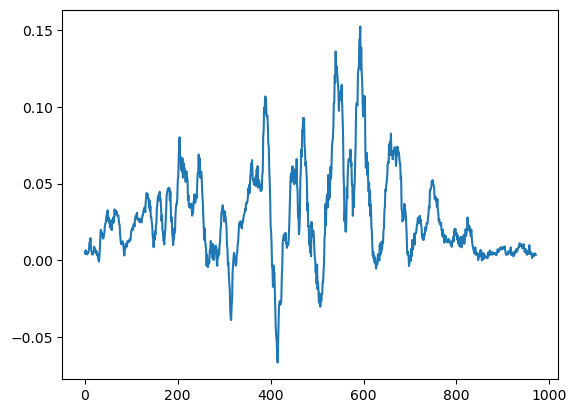

In [19]:
#plot.plot(fawa_eachyr[32,0,:])
plot.plot(epz_eachyr[32,0,:])
# plot.plot(ubar_eachyr[64,0,:])
# plot.plot(uref_eachyr[64,0,:])
plot.show()

In [20]:
edz_a_sea = np.zeros((97,992))
adt_sea = np.zeros((97,992))
resi_a_sea = np.zeros((97,992))

edz_u_sea = np.zeros((97,992))
udt_sea = np.zeros((97,992))
resi_u_sea = np.zeros((97,992))

urdt_sea = np.zeros((97,992))
resi_sum_sea = np.zeros((97,992))

dt = 3600*6

alpha = 0.4 #0.4 #0.6
            
for z in range(1,96):
    for d in range(1,991):
        
            edz_a_sea[z,d] =  -np.exp(height[z]/hh) * (epz_sea[z+1,d] - epz_sea[z-1,d])/dz/2 
            adt_sea[z,d] = (fawa_sea[z,d+1] - fawa_sea[z,d-1])/2/dt
            resi_a_sea[z,d] = adt_sea[z,d] - edz_a_sea[z,d]            
            
            edz_u_sea[z,d] =  alpha *np.exp(height[z]/hh) * (epz_sea[z+1,d] - epz_sea[z-1,d])/dz/2 
            udt_sea[z,d] = (ubar_sea[z,d+1] - ubar_sea[z,d-1])/2/dt
            resi_u_sea[z,d] = udt_sea[z,d] - edz_u_sea[z,d]

            urdt_sea[z,d] = (uref_sea[z,d+1] - uref_sea[z,d-1])/2/dt
            resi_sum_sea[z,d] = 0.4*resi_a_sea[z,d]+resi_u_sea[z,d]
            

In [21]:
edz_a_eachyr = np.zeros((97,42,992))
adt_eachyr = np.zeros((97,42,992))
astardt_eachyr = np.zeros((97,42,992))
resi_a_eachyr = np.zeros((97,42,992))
resi_star_a_eachyr = np.zeros((97,42,992))

edz_u_eachyr = np.zeros((97,42,992))
udt_eachyr = np.zeros((97,42,992))
ustardt_eachyr = np.zeros((97,42,992))
resi_u_eachyr = np.zeros((97,42,992))
resi_star_u_eachyr = np.zeros((97,42,992))

urdt_eachyr = np.zeros((97,42,992))
resi_sum_eachyr = np.zeros((97,42,992))

dt = 3600*6

alpha = 0.4 #0.4 #0.4

for yy in range(42):
    for z in range(1,96):
        for d in range(1,991):
                edz_a_eachyr[z,yy,d] =  -np.exp(height[z]/hh) * (epz_eachyr[z+1,yy,d] - epz_eachyr[z-1,yy,d])/dz/2 
                adt_eachyr[z,yy,d] = (fawa_eachyr[z,yy,d+1] - fawa_eachyr[z,yy,d-1])/2/dt
                resi_a_eachyr[z,yy,d] = adt_eachyr[z,yy,d] - edz_a_eachyr[z,yy,d]

                edz_u_eachyr[z,yy,d] =  alpha*np.exp(height[z]/hh) * (epz_eachyr[z+1,yy,d] - epz_eachyr[z-1,yy,d])/dz/2 
                udt_eachyr[z,yy,d] = (ubar_eachyr[z,yy,d+1] - ubar_eachyr[z,yy,d-1])/2/dt
                resi_u_eachyr[z,yy,d] = udt_eachyr[z,yy,d] - edz_u_eachyr[z,yy,d]

                urdt_eachyr[z,yy,d] = (uref_eachyr[z,yy,d+1] - uref_eachyr[z,yy,d-1])/2/dt
                resi_sum_eachyr[z,yy,d] = alpha*resi_a_eachyr[z,yy,d]+resi_u_eachyr[z,yy,d]

In [22]:
gamma = 1.4e-6
miu_a = 0
miu_u = 0

epsilon = 70
k = 2.3e-7 * epsilon**2
# k = 0.001127
# epsilon = np.sqrt(k/2.3e-7)
alpha = 0.6 #0.6

kappa = 1/ ( 50*24*3600)

uref_urad = np.zeros((97,992))
urad = np.zeros((97,992))
urad0 = np.zeros((97,992))
ud = np.zeros((97,992))

dt = 3600*6

for z in range(1,96):
    for d in range(1,991):
        uref_urad[z,d] = udt_sea[z,d] - alpha*np.exp(height[z]/hh) * (epz_sea[z+1,d] - epz_sea[z-1,d])/dz/2 + kappa*ubar_sea[z,d] 
        #urdt_sea[z,d] + k*fawa_sea_octmay[z,d] /( ubar_sea_octmay[z,d]**2 + epsilon**2 ) # + kappa*ubar_sea_octmay[z,d]
        urad0[z,d] = ubar_sea[z,d]+uref_urad[z,d]/gamma
        urad[z,d] = ubar_sea[z,d]+uref_urad[z,d]/gamma #+ 0.2*fawa_sea[z,d] # -gamma * ( ur[z,d] - ud[z,d] )
        
urad[:, 971:] = np.tile(urad[:, 970:971], (1, 992-971))

from scipy.signal import savgol_filter
ud[2:95,:] = savgol_filter(urad[2:95,:], window_length=101, polyorder=2)

#ud = np.hstack((ud,np.zeros((97,22))))

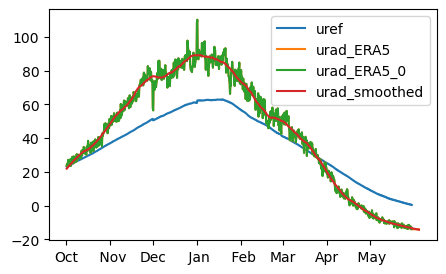

In [23]:
#plot.plot(uref_urad[64,1:483])

x = np.arange(0,992,1)/4

plot.figure(figsize=(5,3))  # Smaller figure size
plot.plot(x[1:],uref_sea[64,1:],label='uref')
plot.plot(x[1:],urad[64,1:],label='urad_ERA5')
plot.plot(x[1:],urad0[64,1:],label='urad_ERA5_0')
plot.plot(x[1:],ud[64,1:],label='urad_smoothed')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
#plot.xticks(ticks=[0,31,61,92,123], labels=[' Nov', 'Dec',' Jan',' Feb', 'Mar'])
# plot.plot(-uref_sea_octmay[64,1:]+ud[64,1:],label='urad_smoothed')
plot.legend()


In [24]:
ud_ssw = np.repeat(ud[:, np.newaxis, :], 42, axis=1)
# ud_ssw[-1,:,:] = ud_ssw[-3,:,:]
# ud_ssw[-2,:,:] = ud_ssw[-3,:,:]

In [25]:
from scipy.interpolate import interp1d

hhh = np.arange(0,zdim,1)*(100/zdim)+10.

# Create interpolator function
ud_ssw_interp = np.zeros((zdim, 42, 992))
for y in range(42):
    for t in range(992):
        # Create interpolator for each year and time step
        f = interp1d(height/1000, ud_ssw[:,y,t], kind='linear', bounds_error=False, fill_value=(ud_ssw[0,y,t], ud_ssw[-1,y,t]))
        # Interpolate to new height levels
        ud_ssw_interp[:,y,t] = f(hhh)

In [26]:
# Check for NaN values in the interpolated data
print("Number of NaN values:", np.isnan(ud_ssw_interp).sum())
print("Shape of data:", ud_ssw_interp.shape)
print("Min value:", np.nanmin(ud_ssw_interp))
print("Max value:", np.nanmax(ud_ssw_interp))

# # Display the data
# ud_ssw_interp

Number of NaN values: 0
Shape of data: (501, 42, 992)
Min value: -38.838140076313415
Max value: 360.77654388636455


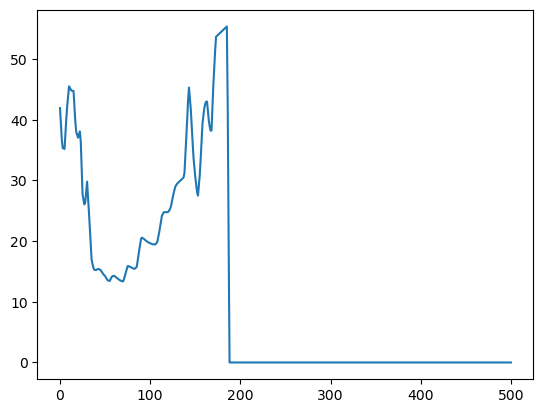

In [27]:
plot.plot(ud_ssw_interp[:,0,0])

In [28]:
# import netCDF4 as nc
# import numpy as np

# # Create a new netCDF file
# ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/urad_97.nc', mode='w', format='NETCDF4')

# # Define dimensions
# time_dim = ncfile.createDimension('height', 97)
# lat_dim = ncfile.createDimension('year', 42)
# lon_dim = ncfile.createDimension('time', 992)

# # Create variables
# u_estimated_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# # Write data to variables
# u_estimated_var[:] = ud_ssw

# # Close the file
# ncfile.close()

In [29]:
import netCDF4 as nc
import numpy as np

# Create a new netCDF file
ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_'+str(zdim)+'.nc', mode='w', format='NETCDF4')

# Define dimensions
time_dim = ncfile.createDimension('height', zdim)
lat_dim = ncfile.createDimension('year', 42)
lon_dim = ncfile.createDimension('time', 992)

# Create variables
u_estimated_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# Write data to variables
u_estimated_var[:] = ud_ssw_interp

# Close the file
ncfile.close()


In [30]:
uref.shape

(97, 124, 12, 43)

In [ ]:
# t  Oct 1 
t = np.arange(uref_sea.shape[1]) / 4.0

# 
t0_day = 102.0   #  Apr 1
t1_day = t[-1]   #  May 31

# 0~11= uref0.6= 60%
eta = 0.99

# tapert<t0 0t0->t1 0 etat>=t1  eta
w = np.zeros_like(t)
seg = (t >= t0_day) & (t <= t1_day)
w[seg] = eta * 0.5 * (1 - np.cos(np.pi * (t[seg] - t0_day) / (t1_day - t0_day)))
w[t > t1_day] = eta

# tm = 0.5 * (t0_day + t1_day)      # 
# k  = 30.0 / (t1_day - t0_day)     # 
# w = eta / (1 + np.exp(-k * (t - tm)))
# w[t < t0_day] = 0
# w[t > t1_day] = eta


#  (z, time)
W = np.broadcast_to(w, uref_sea.shape)

# A uref 
urad_lifted = urad * (1 - W) + uref_sea * W

# 
urad_smoothed_lifted = ud * (1 - W) + uref_sea * W

urad_smoothed_lifted[:, 971:] = np.tile(urad_smoothed_lifted[:, 970:971], (1, 992-971))

# Savitzky-Golay
# from scipy.signal import savgol_filter
# urad_lifted = savgol_filter(urad_lifted, window_length=9, polyorder=2, axis=1)
# urad_smoothed_lifted = savgol_filter(urad_smoothed_lifted, window_length=9, polyorder=2, axis=1)


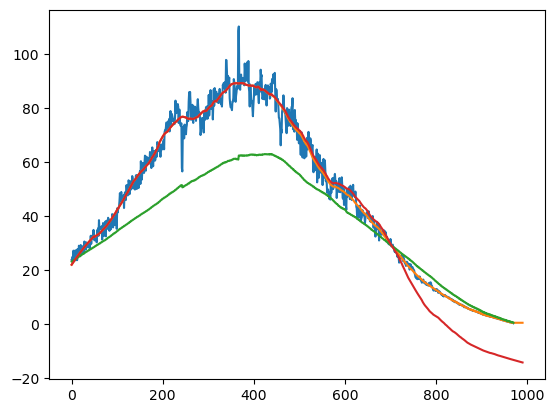

In [ ]:
plot.plot(urad_lifted[64,1:])
plot.plot(urad_smoothed_lifted[64,1:])
plot.plot(uref_sea[64,1:])
plot.plot(ud[64,1:])
plot.show()

In [ ]:
ud_ssw = np.repeat(urad_smoothed_lifted[:, np.newaxis, :], 42, axis=1)

from scipy.interpolate import interp1d

hhh = np.arange(0,zdim,1)*(100/zdim)+10.

# Create interpolator function
ud_ssw_interp = np.zeros((zdim, 42, 992))
for y in range(42):
    for t in range(992):
        # Create interpolator for each year and time step
        f = interp1d(height/1000, ud_ssw[:,y,t], kind='linear', bounds_error=False, fill_value=(ud_ssw[0,y,t], ud_ssw[-1,y,t]))
        # Interpolate to new height levels
        ud_ssw_interp[:,y,t] = f(hhh)

In [ ]:
print("Number of NaN values:", np.isnan(ud_ssw_interp).sum())
print("Shape of data:", ud_ssw_interp.shape)
print("Min value:", np.nanmin(ud_ssw_interp))
print("Max value:", np.nanmax(ud_ssw_interp))

Number of NaN values: 0
Shape of data: (501, 42, 992)
Min value: -35.721401309510085
Max value: 360.77654388636455


In [ ]:
import netCDF4 as nc
import numpy as np

# Create a new netCDF file
ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_'+str(zdim)+'.nc', mode='w', format='NETCDF4')

# Define dimensions
time_dim = ncfile.createDimension('height', zdim)
lat_dim = ncfile.createDimension('year', 42)
lon_dim = ncfile.createDimension('time', 992)

# Create variables
u_estimated_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# Write data to variables
u_estimated_var[:] = ud_ssw_interp

# Close the file
ncfile.close()

In [ ]:
# import netCDF4 as nc
# import numpy as np

# # Create a new netCDF file
# ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/urad_ranforc.nc', mode='w', format='NETCDF4')

# # Define dimensions
# time_dim = ncfile.createDimension('height', 1001)
# lon_dim = ncfile.createDimension('time', 992)

# # Create variables
# u_estimated_var = ncfile.createVariable('urad', np.float32, ('height', 'time'))

# # Write data to variables
# u_estimated_var[:] = ud_ssw_interp[:,0,:]

# # Close the file
# ncfile.close()

In [ ]:
from netCDF4 import Dataset

# 
file_path = "/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad.nc"

#  NetCDF 
ncfile = Dataset(file_path, "r")

# 
print(ncfile)

# 
print("Dimensions:", ncfile.dimensions.keys())

# 
print("Variables:", ncfile.variables.keys())

#  'urad' 
urad = ncfile.variables["urad"][:]
print("urad shape:", urad.shape)

# 
print(ncfile.variables["urad"])


<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): height(201), year(42), time(992)
    variables(dimensions): float32 urad(height, year, time)
    groups: 
Dimensions: dict_keys(['height', 'year', 'time'])
Variables: dict_keys(['urad'])
urad shape: (201, 42, 992)
<class 'netCDF4._netCDF4.Variable'>
float32 urad(height, year, time)
unlimited dimensions: 
current shape = (201, 42, 992)
filling on, default _FillValue of 9.969209968386869e+36 used


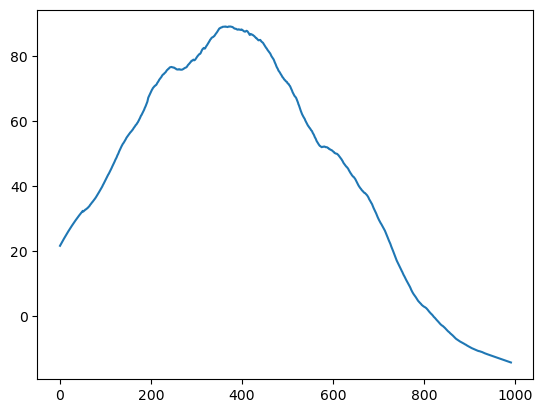

In [ ]:
plot.plot(urad[44,0,:])

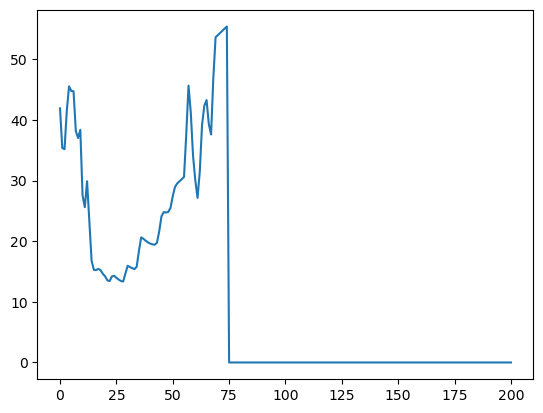

In [ ]:
plot.plot(urad[:,0,0])